In [ ]:
import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
from tqdm import tqdm
import shutil
from google.colab import drive

# ==============================================================================
# 0. CONNECT TO GOOGLE DRIVE (To prevent data loss)
# ==============================================================================
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# Create a folder for your project in Drive (If it doesn't exist)
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'
if not os.path.exists(drive_project_path):
    os.makedirs(drive_project_path)
print(f"Data will be backed up to this folder in Drive: {drive_project_path}")

# ==============================================================================
# 1. DOWNLOAD MS-COCO DATASET (Using Fast Linux Commands)
# ==============================================================================
print("Downloading and extracting MS-COCO annotations and images...")

# Download and extract annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip -q
!unzip -q annotations_trainval2014.zip -d /content/
annotation_file = '/content/annotations/captions_train2014.json'

# Download and extract images
!wget http://images.cocodataset.org/zips/train2014.zip -q
!unzip -q train2014.zip -d /content/
PATH = '/content/train2014/'

print("Download and extraction complete!")

# ==============================================================================
# 2. LOAD ANNOTATIONS AND LIMIT DATASET
# ==============================================================================
with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)
train_image_paths = image_paths[:30000]

train_captions = []
img_name_vector = []

for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    train_captions.extend(caption_list)
    img_name_vector.extend([image_path] * len(caption_list))

print(f"Total number of captions: {len(train_captions)}")
print(f"Total number of unique images to process: {len(set(img_name_vector))}")

# ==============================================================================
# 3. PREPARE VGG16 ENCODER
# ==============================================================================
def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, image_path

image_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-1].output
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

# ==============================================================================
# 4. EXTRACT FEATURES AND SAVE TO DISK (.npy)
# ==============================================================================
encode_train = sorted(set(img_name_vector))
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
image_dataset = image_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(16)

print("Starting feature extraction on Colab GPU...")

for img, path in tqdm(image_dataset):
    batch_features = image_features_extract_model(img)
    batch_features = tf.reshape(batch_features, (batch_features.shape[0], -1, batch_features.shape[3]))

    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        np.save(path_of_feature, bf.numpy())

print("Feature extraction complete!")

# ==============================================================================
# 5. BACKUP (Moving Features to Drive)
# ==============================================================================
print("Extracted features are being zipped and copied to Google Drive. Please wait...")
import glob
npy_files = glob.glob('/content/train2014/*.npy')

# Collect all npy files into a single folder
backup_folder = '/content/extracted_features'
os.makedirs(backup_folder, exist_ok=True)

for f in npy_files:
    shutil.move(f, backup_folder)

# Zip and move to Drive
shutil.make_archive(f"{drive_project_path}/coco_vgg16_features", 'zip', backup_folder)

print(f"AWESOME! All operations are complete. Features are saved to your Drive ({drive_project_path}).")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be backed up to this folder in Drive: /content/drive/MyDrive/MS_COCO_Project
Download and extraction complete!
Total number of captions: 150074
Total number of unique images to process: 30000
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting feature extraction on Colab GPU...


100%|██████████| 1875/1875 [03:24<00:00,  9.16it/s]


Feature extraction complete!
Extracted features are being zipped and copied to Google Drive. Please wait...
AWESOME! All operations are complete. Features are saved to your Drive (/content/drive/MyDrive/MS_COCO_Project).


In [ ]:
import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
import shutil
import time
from google.colab import drive

# 1. MOUNT GOOGLE DRIVE
print("Connecting to Google Drive...")
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'

# 2. RESTORE FILES TO COLAB LOCAL STORAGE (For high performance)
print("Restoring features and annotations to local runtime...")

# Unzip features from Drive to local /content/ folder
if not os.path.exists('/content/extracted_features'):
    print("Unzipping features (this may take a minute)...")
    !unzip -q {drive_project_path}/coco_vgg16_features.zip -d /content/extracted_features

# Re-download and unzip annotations
if not os.path.exists('/content/annotations'):
    print("Downloading annotations...")
    !wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip -q
    !unzip -q annotations_trainval2014.zip -d /content/

# 3. RE-INITIALIZE DATA STRUCTURES & TOKENIZER
print("Re-initializing Tokenizer and Data structures...")
annotation_file = '/content/annotations/captions_train2014.json'

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    # Path needs to match the original structure for the vector
    image_path = '/content/train2014/COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)
train_image_paths = image_paths[:30000]

train_captions = []
img_name_vector = []
for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    train_captions.extend(caption_list)
    img_name_vector.extend([image_path] * len(caption_list))

# Re-create the exact same Tokenizer
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters=r'!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(train_captions)
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

train_seqs = tokenizer.texts_to_sequences(train_captions)
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

# 4. RE-CREATE DATASET PIPELINE
BATCH_SIZE = 64
BUFFER_SIZE = 1000
vocab_size = top_k + 1
embedding_dim = 256
units = 512
num_steps = len(img_name_vector) // BATCH_SIZE

def map_func(img_name, cap):
    img_name_str = img_name.decode('utf-8')
    # Get the filename (e.g., COCO_train2014_000000XXXXXX.jpg)
    img_id = img_name_str.split('/')[-1]
    # Point to the local extracted_features folder
    npy_path = '/content/extracted_features/' + img_id + '.npy'
    img_tensor = np.load(npy_path)
    return img_tensor, cap

dataset = tf.data.Dataset.from_tensor_slices((img_name_vector, cap_vector))
dataset = dataset.map(lambda item1, item2: tf.numpy_function(
          map_func, [item1, item2], [tf.float32, tf.int32]),
          num_parallel_calls=tf.data.AUTOTUNE)

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# Define loss function again
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

print("\n ENVIRONMENT RESTORED! ")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restoring features and annotations to local runtime...
Unzipping features (this may take a minute)...
Re-initializing Tokenizer and Data structures...

 ENVIRONMENT RESTORED! 


In [ ]:
import os
from google.colab import drive

# ==============================================================================
# 1. MOUNT GOOGLE DRIVE & RESTORE FILES
# ==============================================================================
print("1. Connecting to Google Drive...")
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'

print("2. Pulling features and annotations from Drive (Please wait)...")

# Unzip features from Drive to local /content/ folder
if not os.path.exists('/content/extracted_features'):
    !unzip -q {drive_project_path}/coco_vgg16_features.zip -d /content/extracted_features

# Re-download and unzip annotations
if not os.path.exists('/content/annotations'):
    !wget http://images.cocodataset.org/annotations/annotations_trainval2014.zip -q
    !unzip -q annotations_trainval2014.zip -d /content/

print("\n ENVIRONMENT READY! You can now run the Main Training Code below.")

1. Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2. Pulling features and annotations from Drive (Please wait)...

 ENVIRONMENT READY! You can now run the Main Training Code below.


In [ ]:
import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
import time
import gc
from google.colab import drive

# ==============================================================================
# 1. ENVIRONMENT SETTINGS AND DATA LOADING
# ==============================================================================
print("1. Mounting Drive and preparing data for PHASE 1 (Baseline)...")
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'

annotation_file = '/content/annotations/captions_train2014.json'
PATH = '/content/train2014/'

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)

# 80% Train / 20% Validation split from the 30,000 subset
total_subset = image_paths[:30000]
split_index = int(len(total_subset) * 0.8)

train_image_paths = total_subset[:split_index]
val_image_paths = total_subset[split_index:]

def prepare_vectors(paths):
    captions = []
    names = []
    for image_path in paths:
        caption_list = image_path_to_caption[image_path]
        captions.extend(caption_list)
        names.extend([image_path] * len(caption_list))
    return captions, names

train_captions, img_name_vector = prepare_vectors(train_image_paths)
val_captions, img_name_val_vector = prepare_vectors(val_image_paths)

# ==============================================================================
# 2. TOKENIZATION AND PADDING
# ==============================================================================
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters=r'!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(train_captions)

tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

train_seqs = tokenizer.texts_to_sequences(train_captions)
val_seqs = tokenizer.texts_to_sequences(val_captions)

max_length = max(len(t) for t in train_seqs)
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, maxlen=max_length, padding='post')
cap_val_vector = tf.keras.preprocessing.sequence.pad_sequences(val_seqs, maxlen=max_length, padding='post')

# ==============================================================================
# 3. DATASET CREATION
# ==============================================================================
BATCH_SIZE = 64
BUFFER_SIZE = 1000
vocab_size = top_k + 1
embedding_dim = 256
units = 512

def map_func(img_name, cap):
    if isinstance(img_name, bytes):
        img_name_str = img_name.decode('utf-8')
    else:
        img_name_str = img_name

    img_id = img_name_str.split('/')[-1]
    npy_path = '/content/extracted_features/' + img_id + '.npy'

    img_tensor = np.load(npy_path)
    return img_tensor, cap

dataset = tf.data.Dataset.from_tensor_slices((img_name_vector, cap_vector))
dataset = dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                      num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((img_name_val_vector, cap_val_vector))
val_dataset = val_dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                              num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ==============================================================================
# 4. BASELINE ARCHITECTURE (NO ATTENTION)
# ==============================================================================
class BaselineDecoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, cell_type, num_layers):
        super(BaselineDecoder, self).__init__()
        self.units = units
        self.cell_type = cell_type.upper()
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        self.feature_projector = tf.keras.layers.Dense(units)

        self.rnn_cells = []
        for _ in range(num_layers):
            if self.cell_type == 'LSTM':
                self.rnn_cells.append(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
            else: # GRU
                self.rnn_cells.append(tf.keras.layers.GRU(units, return_sequences=True, return_state=True))

        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):
        # NO ATTENTION: Just project and take the mean of the 49 regions
        features = self.feature_projector(features)
        context_vector = tf.reduce_mean(features, axis=1) # Shape: (batch_size, units)

        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        new_hidden = []
        for i in range(self.num_layers):
            if self.cell_type == 'LSTM':
                x, h, c = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append([h, c])
            else:
                x, h = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append(h)

        x = self.fc2(self.fc1(x))

        # Dummy attention weights to prevent test code from crashing
        dummy_attention = tf.zeros((tf.shape(x)[0], 49))

        return tf.reshape(x, (-1, x.shape[2])), new_hidden, dummy_attention

    def init_hidden_state(self, batch_size):
        if self.cell_type == 'LSTM':
            return [[tf.zeros((batch_size, self.units)), tf.zeros((batch_size, self.units))] for _ in range(self.num_layers)]
        return [tf.zeros((batch_size, self.units)) for _ in range(self.num_layers)]

# ==============================================================================
# 5. TRAINING MANAGER
# ==============================================================================
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    return tf.reduce_mean(loss_ * tf.cast(mask, dtype=loss_.dtype))

def run_baseline_experiment(cell_type, num_layers, epochs=5):
    print(f"\n>>> PHASE 1 EXPERIMENT STARTING: {cell_type} | Layers: {num_layers} | NO Attention | NO Teacher Forcing")
    model = BaselineDecoder(embedding_dim, units, vocab_size, cell_type, num_layers)
    optimizer = tf.keras.optimizers.Adam()

    checkpoint_dir = os.path.join(drive_project_path, f"checkpoints_{cell_type}_L{num_layers}")
    os.makedirs(checkpoint_dir, exist_ok=True)

    epoch_var = tf.Variable(0, dtype=tf.int32)
    checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model, epoch=epoch_var)
    manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=1)

    if manager.latest_checkpoint:
        checkpoint.restore(manager.latest_checkpoint)
        print(f" => KAYIT BULUNDU! Eğitim kaldığı yerden ({epoch_var.numpy() + 1}. Epoch) devam ediyor...")
    else:
        print(" => Önceki kayıt bulunamadı. 1. Epoch'tan başlanıyor...")

    start_epoch = epoch_var.numpy()

    if start_epoch >= epochs:
        print(f" => {cell_type} L{num_layers} modeli zaten {epochs} epoch tamamlamış. Bu deney atlanıyor.")
        return

    @tf.function
    def train_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

        with tf.GradientTape() as tape:
            for i in range(1, target.shape[1]):
                predictions, hidden, _ = model(dec_input, img_tensor, hidden)
                loss += loss_function(target[:, i], predictions)

                predicted_id = tf.argmax(predictions, axis=1)
                dec_input = tf.expand_dims(predicted_id, 1)

        avg_loss = (loss / int(target.shape[1]))
        optimizer.apply_gradients(zip(tape.gradient(loss, model.trainable_variables), model.trainable_variables))
        return avg_loss

    @tf.function
    def val_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

        for i in range(1, target.shape[1]):
            predictions, hidden, _ = model(dec_input, img_tensor, hidden)
            loss += loss_function(target[:, i], predictions)

            predicted_id = tf.argmax(predictions, axis=1)
            dec_input = tf.expand_dims(predicted_id, 1)

        return (loss / int(target.shape[1]))

    for epoch in range(start_epoch, epochs):
        start = time.time()
        print(f"\n--- Starting Epoch {epoch+1}/{epochs} ---")

        total_train_loss = 0
        for (batch, (img, targ)) in enumerate(dataset):
            t_loss = train_step(img, targ)
            total_train_loss += t_loss
            if batch % 100 == 0:
                print(f'   -> Training Progress: Batch {batch} | Current Loss: {t_loss.numpy():.4f}')

        print(f"   -> Calculating Validation...")
        total_val_loss = 0
        for (img, targ) in val_dataset:
            total_val_loss += val_step(img, targ)

        print(f' EPOCH {epoch+1} SUMMARY: Train Loss: {total_train_loss/len(dataset):.4f} | Val Loss: {total_val_loss/len(val_dataset):.4f} | Time: {time.time()-start:.1f}s')

        epoch_var.assign(epoch + 1)
        save_path_ckpt = manager.save()
        print(f" -> İlerleme kaydedildi (Checkpoint): {save_path_ckpt}")

    save_name = f"baseline_{cell_type}_L{num_layers}.weights.h5"
    save_path = os.path.join(drive_project_path, save_name)
    model.save_weights(save_path)
    print(f"Baseline model başarıyla tamamlandı ve kaydedildi: {save_path}")

# ==============================================================================
# 6. RUN PHASE 1 EXPERIMENTS
# ==============================================================================

baseline_experiments = [
    {'cell': 'LSTM', 'layers': 1},
    {'cell': 'GRU',  'layers': 1},
    {'cell': 'LSTM', 'layers': 2},
    {'cell': 'GRU',  'layers': 2}
]

for experiment in baseline_experiments:
    tf.keras.backend.clear_session()
    gc.collect()
    run_baseline_experiment(experiment['cell'], experiment['layers'], epochs=5)

print("\n PHASE 1 COMPLETED! You now have your baseline models without Teacher Forcing or Attention.")

1. Mounting Drive and preparing data for PHASE 1 (Baseline)...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

>>> PHASE 1 EXPERIMENT STARTING: LSTM | Layers: 1 | NO Attention | NO Teacher Forcing
 => Önceki kayıt bulunamadı. 1. Epoch'tan başlanıyor...

--- Starting Epoch 1/5 ---
   -> Training Progress: Batch 0 | Current Loss: 1.8381
   -> Training Progress: Batch 100 | Current Loss: 1.0707
   -> Training Progress: Batch 200 | Current Loss: 1.0075
   -> Training Progress: Batch 300 | Current Loss: 1.0706
   -> Training Progress: Batch 400 | Current Loss: 1.0535
   -> Training Progress: Batch 500 | Current Loss: 0.9816
   -> Training Progress: Batch 600 | Current Loss: 0.9888
   -> Training Progress: Batch 700 | Current Loss: 0.9734
   -> Training Progress: Batch 800 | Current Loss: 0.9451
   -> Training Progress: Batch 900 | Current Loss: 0.9088
   -> Training Progress: Batch 1000 | Current Loss: 0.9821


In [ ]:
!pip install rouge-score -q
import nltk
import urllib.request
import os
import numpy as np
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score

# Download NLTK requirements
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(">>> METRIC CALCULATION STARTING (PHASE 1 - BASELINE MODELS) <<<")

# ==============================================================================
# 1. HELPER FUNCTIONS (Image Downloading and Feature Extraction)
# ==============================================================================
def download_single_image(image_id_str):
    filename = f"COCO_train2014_{int(image_id_str):012d}.jpg"
    url = f"http://images.cocodataset.org/train2014/{filename}"
    local_path = f"/content/{filename}"

    if not os.path.exists(local_path):
        urllib.request.urlretrieve(url, local_path)
    return local_path

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, image_path

# Redefine the feature extractor model (to ensure it's available)
image_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
image_features_extract_model = tf.keras.Model(image_model.input, image_model.layers[-1].output)

# ==============================================================================
# 2. EVALUATE FUNCTION - FOR BASELINE
# ==============================================================================
def evaluate_baseline(image_path, model):
    hidden = model.init_hidden_state(1)

    temp_input, _ = load_image(image_path)
    img_tensor_val = image_features_extract_model(tf.expand_dims(temp_input, 0))
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        # Baseline model does not return attention_weights, ignoring with _
        predictions, hidden, _ = model(dec_input, img_tensor_val, hidden)

        predicted_id = tf.argmax(predictions, axis=1).numpy()[0]
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result

        dec_input = tf.expand_dims([predicted_id], 0)

    return result

# ==============================================================================
# 3. METRIC CALCULATION LOOP
# ==============================================================================
# Selecting an independent test set of 500 unseen images
unseen_test_paths = image_paths[30000:30500]
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

baseline_experiments = [
    {'cell': 'LSTM', 'layers': 1},
    {'cell': 'GRU',  'layers': 1},
    {'cell': 'LSTM', 'layers': 2},
    {'cell': 'GRU',  'layers': 2}
]

print(f"\nTesting on a total of {len(unseen_test_paths)} unseen images...\n")
print("="*65)
print(f"{'MODEL':<15} | {'BLEU-1':<8} | {'BLEU-4':<8} | {'METEOR':<8} | {'ROUGE_L':<8}")
print("-"*65)

best_score = 0
best_model_name = ""

for exp in baseline_experiments:
    test_cell = exp['cell']
    test_layers = exp['layers']

    # Create the model and clear memory
    tf.keras.backend.clear_session()
    test_model = BaselineDecoder(embedding_dim, units, vocab_size, test_cell, test_layers)

    # Pass dummy data to initialize the model
    _ = test_model(tf.zeros((1, 1)), tf.zeros((1, 49, 512)), test_model.init_hidden_state(1))

    # Load weights
    weight_filename = f"baseline_{test_cell}_L{test_layers}.weights.h5"
    weights_path = os.path.join(drive_project_path, weight_filename)

    if not os.path.exists(weights_path):
        print(f"{weight_filename:<15} | {'NOT FOUND - TRAINING MAY NOT BE COMPLETE':<45}")
        continue

    test_model.load_weights(weights_path)

    actual, predicted = list(), list()
    meteor_scores, rouge_l_scores = [], []

    # Generate predictions for each image in the test set
    for img_path in unseen_test_paths:
        img_id = img_path.split('_')[-1].split('.')[0]
        local_path = download_single_image(img_id)

        result = evaluate_baseline(local_path, test_model)

        # Prepare actual texts (references)
        references = [c.split() for c in image_path_to_caption[img_path]]
        ref_texts = [c.replace('<start>', '').replace('<end>', '').strip() for c in image_path_to_caption[img_path]]
        pred_text = ' '.join(result).replace('<end>', '').strip()

        actual.append(references)
        predicted.append(result)

        # Calculate Meteor and Rouge
        meteor_scores.append(meteor_score(references, result))
        r_scores = [scorer.score(rt, pred_text)['rougeL'].fmeasure for rt in ref_texts]
        rouge_l_scores.append(max(r_scores))

    # Calculate corpus-level BLEU Scores
    b1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
    b4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    m_score = np.mean(meteor_scores)
    r_score = np.mean(rouge_l_scores)

    model_name = f"{test_cell} ({test_layers}L)"
    print(f"{model_name:<15} | {b1:<8.4f} | {b4:<8.4f} | {m_score:<8.4f} | {r_score:<8.4f}")

    # Determine the best model based on BLEU-4 (commonly used in image captioning)
    if b4 > best_score:
        best_score = b4
        best_model_name = model_name

print("="*65)
print(f" BEST MODEL ACCORDING TO PHASE 1 RESULTS: {best_model_name} (BLEU-4: {best_score:.4f})")
print("-> Proceed to Phase 2 (Teacher Forcing) ONLY using this model!")

  Preparing metadata (setup.py) ... done
>>> METRIC CALCULATION STARTING (PHASE 1 - BASELINE MODELS) <<<
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Testing on a total of 500 unseen images...

MODEL           | BLEU-1   | BLEU-4   | METEOR   | ROUGE_L 
-----------------------------------------------------------------
LSTM (1L)       | 0.4220   | 0.0309   | 0.2217   | 0.3658  
GRU (1L)        | 0.4120   | 0.0252   | 0.2164   | 0.3698  
LSTM (2L)       | 0.4383   | 0.0389   | 0.2294   | 0.3840  
GRU (2L)        | 0.4354   | 0.0407   | 0.2261   | 0.3805  
 BEST MODEL ACCORDING TO PHASE 1 RESULTS: GRU (2L) (BLEU-4: 0.0407)
-> Proceed to Phase 2 (Teacher Forcing) ONLY using this model!


In [ ]:
# ==============================================================================
# PHASE 2: TEACHER FORCING ON THE BEST MODEL
# ==============================================================================
import tensorflow as tf
import time
import os
import gc

BEST_CELL = 'GRU'
BEST_LAYERS = 2
# ---------------------------------------------

print(f">>> PHASE 2 STARTING: Applying Teacher Forcing to {BEST_CELL} with {BEST_LAYERS} layers")

class TeacherForcingDecoder(BaselineDecoder):
    pass

model_p2 = TeacherForcingDecoder(embedding_dim, units, vocab_size, BEST_CELL, BEST_LAYERS)
optimizer_p2 = tf.keras.optimizers.Adam()

@tf.function
def train_step_p2(img_tensor, target):
    loss = 0
    hidden = model_p2.init_hidden_state(target.shape[0])

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        for i in range(1, target.shape[1]):

            predictions, hidden, _ = model_p2(dec_input, img_tensor, hidden)

            loss += loss_function(target[:, i], predictions)

            dec_input = tf.expand_dims(target[:, i], 1)

    avg_loss = (loss / int(target.shape[1]))
    trainable_variables = model_p2.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer_p2.apply_gradients(zip(gradients, trainable_variables))
    return avg_loss

EPOCHS_P2 = 5
print(f"Starting Phase 2 Training for {EPOCHS_P2} epochs...")

for epoch in range(EPOCHS_P2):
    start = time.time()
    total_loss = 0

    for (batch, (img, targ)) in enumerate(dataset):
        t_loss = train_step_p2(img, targ)
        total_loss += t_loss

        if batch % 100 == 0:
            print(f'Epoch {epoch+1} Batch {batch} Loss {t_loss.numpy():.4f}')

    print(f'Epoch {epoch+1} Loss {total_loss/len(dataset):.4f} Total Time: {time.time()-start:.2f} sec')

save_name_p2 = f"phase2_teacher_forcing_{BEST_CELL}_L{BEST_LAYERS}.weights.h5"
save_path_p2 = os.path.join(drive_project_path, save_name_p2)
model_p2.save_weights(save_path_p2)
print(f"Phase 2 model saved: {save_path_p2}")

>>> PHASE 2 STARTING: Applying Teacher Forcing to GRU with 2 layers
Starting Phase 2 Training for 5 epochs...
Epoch 1 Batch 0 Loss 1.9043
Epoch 1 Batch 100 Loss 1.0595
Epoch 1 Batch 200 Loss 0.9139
Epoch 1 Batch 300 Loss 0.8860
Epoch 1 Batch 400 Loss 0.8523
Epoch 1 Batch 500 Loss 0.8074
Epoch 1 Batch 600 Loss 0.7642
Epoch 1 Batch 700 Loss 0.7239
Epoch 1 Batch 800 Loss 0.7820
Epoch 1 Batch 900 Loss 0.7098
Epoch 1 Batch 1000 Loss 0.8826
Epoch 1 Batch 1100 Loss 0.7242
Epoch 1 Batch 1200 Loss 0.7430
Epoch 1 Batch 1300 Loss 0.7448
Epoch 1 Batch 1400 Loss 0.7783
Epoch 1 Batch 1500 Loss 0.7935
Epoch 1 Batch 1600 Loss 0.7640
Epoch 1 Batch 1700 Loss 0.7262
Epoch 1 Batch 1800 Loss 0.7329
Epoch 1 Loss 0.8161 Total Time: 325.18 sec
Epoch 2 Batch 0 Loss 0.7456
Epoch 2 Batch 100 Loss 0.7834
Epoch 2 Batch 200 Loss 0.6782
Epoch 2 Batch 300 Loss 0.7658
Epoch 2 Batch 400 Loss 0.7437
Epoch 2 Batch 500 Loss 0.7264
Epoch 2 Batch 600 Loss 0.7003
Epoch 2 Batch 700 Loss 0.6692
Epoch 2 Batch 800 Loss 0.7417
Ep

In [ ]:
# ==============================================================================
# PHASE 2: EVALUATION CODE (METRIC CALCULATION)
# ==============================================================================
print(f"\n>>> PHASE 2 METRIC CALCULATION STARTING: {BEST_CELL} ({BEST_LAYERS}L) + Teacher Forcing")

tf.keras.backend.clear_session()
test_model_p2 = TeacherForcingDecoder(embedding_dim, units, vocab_size, BEST_CELL, BEST_LAYERS)
_ = test_model_p2(tf.zeros((1, 1)), tf.zeros((1, 49, 512)), test_model_p2.init_hidden_state(1))

weights_path_p2 = os.path.join(drive_project_path, f"phase2_teacher_forcing_{BEST_CELL}_L{BEST_LAYERS}.weights.h5")

if os.path.exists(weights_path_p2):
    test_model_p2.load_weights(weights_path_p2)
    print("Weights loaded successfully for Phase 2 model.")
else:
    print("ERROR: Weights not found! Please check the path.")

actual_p2, predicted_p2 = list(), list()
meteor_p2, rouge_l_p2 = [], []

print(f"Testing on {len(unseen_test_paths)} unseen images...")

for img_path in unseen_test_paths:
    img_id = img_path.split('_')[-1].split('.')[0]
    local_path = download_single_image(img_id)

    result = evaluate_baseline(local_path, test_model_p2)

    references = [c.split() for c in image_path_to_caption[img_path]]
    ref_texts = [c.replace('<start>', '').replace('<end>', '').strip() for c in image_path_to_caption[img_path]]
    pred_text = ' '.join(result).replace('<end>', '').strip()

    actual_p2.append(references)
    predicted_p2.append(result)

    meteor_p2.append(meteor_score(references, result))
    r_scores = [scorer.score(rt, pred_text)['rougeL'].fmeasure for rt in ref_texts]
    rouge_l_p2.append(max(r_scores))

b1_p2 = corpus_bleu(actual_p2, predicted_p2, weights=(1.0, 0, 0, 0))
b4_p2 = corpus_bleu(actual_p2, predicted_p2, weights=(0.25, 0.25, 0.25, 0.25))
m_score_p2 = np.mean(meteor_p2)
r_score_p2 = np.mean(rouge_l_p2)

print("\n" + "="*75)
print(f"{'PHASE (Model Strategy)':<30} | {'BLEU-1':<8} | {'BLEU-4':<8} | {'METEOR':<8} | {'ROUGE_L':<8}")
print("-" * 75)

print(f"{f'PHASE 2: {BEST_CELL} ({BEST_LAYERS}L) + TF':<30} | {b1_p2:<8.4f} | {b4_p2:<8.4f} | {m_score_p2:<8.4f} | {r_score_p2:<8.4f}")
print("="*75)

print("\nCOMPARE: Compare these results with your Phase 1 table. You should see an improvement!")


>>> PHASE 2 METRIC CALCULATION STARTING: GRU (2L) + Teacher Forcing
Weights loaded successfully for Phase 2 model.
Testing on 500 unseen images...

PHASE (Model Strategy)         | BLEU-1   | BLEU-4   | METEOR   | ROUGE_L 
---------------------------------------------------------------------------
PHASE 2: GRU (2L) + TF         | 0.5718   | 0.1259   | 0.3478   | 0.4567  

COMPARE: Compare these results with your Phase 1 table. You should see an improvement!


In [ ]:
import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
import time
import gc
from google.colab import drive

# ==============================================================================
# 1. ENVIRONMENT SETTINGS AND DATA LOADING
# ==============================================================================
print("1. Mounting Drive and preparing data...")
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'

annotation_file = '/content/annotations/captions_train2014.json'
PATH = '/content/train2014/'

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)

# 80% Train / 20% Validation split from the 30,000 subset
total_subset = image_paths[:30000]
split_index = int(len(total_subset) * 0.8)

train_image_paths = total_subset[:split_index]
val_image_paths = total_subset[split_index:]

def prepare_vectors(paths):
    captions = []
    names = []
    for image_path in paths:
        caption_list = image_path_to_caption[image_path]
        captions.extend(caption_list)
        names.extend([image_path] * len(caption_list))
    return captions, names

train_captions, img_name_vector = prepare_vectors(train_image_paths)
val_captions, img_name_val_vector = prepare_vectors(val_image_paths)

# ==============================================================================
# 2. TOKENIZATION AND PADDING
# ==============================================================================
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters=r'!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(train_captions)

tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

train_seqs = tokenizer.texts_to_sequences(train_captions)
val_seqs = tokenizer.texts_to_sequences(val_captions)

max_length = max(len(t) for t in train_seqs)
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, maxlen=max_length, padding='post')
cap_val_vector = tf.keras.preprocessing.sequence.pad_sequences(val_seqs, maxlen=max_length, padding='post')

# ==============================================================================
# 3. DATASET CREATION (WITH SAFE MAP_FUNC)
# ==============================================================================
BATCH_SIZE = 64
BUFFER_SIZE = 1000
vocab_size = top_k + 1
embedding_dim = 256
units = 512

def map_func(img_name, cap):
    if isinstance(img_name, bytes):
        img_name_str = img_name.decode('utf-8')
    else:
        img_name_str = img_name

    img_id = img_name_str.split('/')[-1]
    npy_path = '/content/extracted_features/' + img_id + '.npy'

    img_tensor = np.load(npy_path)
    return img_tensor, cap

# Train Dataset
dataset = tf.data.Dataset.from_tensor_slices((img_name_vector, cap_vector))
dataset = dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                      num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((img_name_val_vector, cap_val_vector))
val_dataset = val_dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                              num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ==============================================================================
# 4. ARCHITECTURE (BONUS #2: REGION-BASED ATTENTION & DECODER)
# ==============================================================================
class GlobalAttention(tf.keras.Model):
    def __init__(self, units, attention_type='bahdanau'):
        super(GlobalAttention, self).__init__()
        self.attention_type = attention_type.lower()

        # Region Projection: Bonus 2
        self.region_projector = tf.keras.layers.Dense(units)

        if self.attention_type == 'bahdanau':
            self.W1 = tf.keras.layers.Dense(units)
            self.W2 = tf.keras.layers.Dense(units)
            self.V = tf.keras.layers.Dense(1)
        elif self.attention_type == 'luong':
            self.W = tf.keras.layers.Dense(units)

    def call(self, features, hidden):
        # Bonus 2: Features (49, 512)
        features = self.region_projector(features)

        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        if self.attention_type == 'bahdanau':
            score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis)))
        elif self.attention_type == 'luong':
            query = self.W(hidden_with_time_axis)
            score = tf.matmul(features, query, transpose_b=True)
        else: # scaled_dot
            dk = tf.cast(features.shape[-1], tf.float32)
            score = tf.matmul(features, hidden_with_time_axis, transpose_b=True) / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = tf.reduce_sum(attention_weights * features, axis=1)
        return context_vector, attention_weights

class UniversalDecoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, cell_type, num_layers, attention_type):
        super(UniversalDecoder, self).__init__()
        self.units = units
        self.cell_type = cell_type.upper()
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # Bonus 2
        self.attention = GlobalAttention(units, attention_type)

        self.rnn_cells = []
        for _ in range(num_layers):
            if self.cell_type == 'LSTM':
                self.rnn_cells.append(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
            else: # GRU
                self.rnn_cells.append(tf.keras.layers.GRU(units, return_sequences=True, return_state=True))

        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):
        h_query = hidden[0][0] if self.cell_type == 'LSTM' else hidden[0]
        context_vector, attention_weights = self.attention(features, h_query)

        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        new_hidden = []
        for i in range(self.num_layers):
            if self.cell_type == 'LSTM':
                x, h, c = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append([h, c])
            else:
                x, h = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append(h)

        x = self.fc2(self.fc1(x))
        return tf.reshape(x, (-1, x.shape[2])), new_hidden, attention_weights

    def init_hidden_state(self, batch_size):
        if self.cell_type == 'LSTM':
            return [[tf.zeros((batch_size, self.units)), tf.zeros((batch_size, self.units))] for _ in range(self.num_layers)]
        return [tf.zeros((batch_size, self.units)) for _ in range(self.num_layers)]

# ==============================================================================
# 5. TRAINING MANAGER
# ==============================================================================
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    return tf.reduce_mean(loss_ * tf.cast(mask, dtype=loss_.dtype))

def run_experiment(cell_type, num_layers, attention_type, epochs=5):
    print(f"\n>>> EXPERIMENT STARTING (Region Attention): {cell_type} | Layers: {num_layers} | Attention: {attention_type}")
    model = UniversalDecoder(embedding_dim, units, vocab_size, cell_type, num_layers, attention_type)
    optimizer = tf.keras.optimizers.Adam()

    @tf.function
    def train_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
        with tf.GradientTape() as tape:
            for i in range(1, target.shape[1]):
                predictions, hidden, _ = model(dec_input, img_tensor, hidden)
                loss += loss_function(target[:, i], predictions)
                dec_input = tf.expand_dims(target[:, i], 1)
        avg_loss = (loss / int(target.shape[1]))
        optimizer.apply_gradients(zip(tape.gradient(loss, model.trainable_variables), model.trainable_variables))
        return avg_loss

    @tf.function
    def val_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
        for i in range(1, target.shape[1]):
            predictions, hidden, _ = model(dec_input, img_tensor, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)
        return (loss / int(target.shape[1]))

    for epoch in range(epochs):
        start = time.time()
        print(f"\n--- Starting Epoch {epoch+1}/{epochs} ---")

        # Training loop
        total_train_loss = 0
        for (batch, (img, targ)) in enumerate(dataset):
            t_loss = train_step(img, targ)
            total_train_loss += t_loss

            # Prints progress every 100 batches
            if batch % 100 == 0:
                print(f'   -> Training Progress: Batch {batch} | Current Loss: {t_loss.numpy():.4f}')

        # Validation loop
        print(f"   -> Calculating Validation...")
        total_val_loss = 0
        for (img, targ) in val_dataset:
            total_val_loss += val_step(img, targ)

        print(f' EPOCH {epoch+1} SUMMARY: Train Loss: {total_train_loss/len(dataset):.4f} | Val Loss: {total_val_loss/len(val_dataset):.4f} | Time: {time.time()-start:.1f}s')

    save_name = f"decoder_{cell_type}_L{num_layers}_{attention_type}.weights.h5"
    save_path = os.path.join(drive_project_path, save_name)
    model.save_weights(save_path)
    print(f"Model saved to: {save_path}")

# ==============================================================================
# 6. BATCH EXPERIMENT RUNNER
# ==============================================================================
experiment_list = [
    {'cell': 'GRU', 'layers': 2, 'attn': 'bahdanau'},
    {'cell': 'GRU', 'layers': 2, 'attn': 'luong'},
    {'cell': 'GRU', 'layers': 2, 'attn': 'scaled_dot'}
]

for experiment in experiment_list:
    tf.keras.backend.clear_session()
    gc.collect()

    run_experiment(experiment['cell'], experiment['layers'], experiment['attn'], epochs=5)

print("\n ALL EXPERIMENTS COMPLETED SUCCESSFULLY WITH REGION ATTENTION!")

1. Mounting Drive and preparing data...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

>>> EXPERIMENT STARTING (Region Attention): GRU | Layers: 2 | Attention: bahdanau

--- Starting Epoch 1/5 ---
   -> Training Progress: Batch 0 | Current Loss: 2.0016
   -> Training Progress: Batch 100 | Current Loss: 1.0265
   -> Training Progress: Batch 200 | Current Loss: 0.8784
   -> Training Progress: Batch 300 | Current Loss: 0.8088
   -> Training Progress: Batch 400 | Current Loss: 0.7689
   -> Training Progress: Batch 500 | Current Loss: 0.7602
   -> Training Progress: Batch 600 | Current Loss: 0.7230
   -> Training Progress: Batch 700 | Current Loss: 0.7059
   -> Training Progress: Batch 800 | Current Loss: 0.7638
   -> Training Progress: Batch 900 | Current Loss: 0.7203
   -> Training Progress: Batch 1000 | Current Loss: 0.6874
   -> Training Progress: Batch 1100 | Current Loss: 0.6902
   -> Training Progress:

In [ ]:
import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
import time
import gc
from google.colab import drive

# ==============================================================================
# 1. ENVIRONMENT SETTINGS AND DATA LOADING
# ==============================================================================
print("1. Mounting Drive and preparing data...")
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'

annotation_file = '/content/annotations/captions_train2014.json'
PATH = '/content/train2014/'

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)

# 80% Train / 20% Validation split from the 30,000 subset
total_subset = image_paths[:30000]
split_index = int(len(total_subset) * 0.8)

train_image_paths = total_subset[:split_index]
val_image_paths = total_subset[split_index:]

def prepare_vectors(paths):
    captions = []
    names = []
    for image_path in paths:
        caption_list = image_path_to_caption[image_path]
        captions.extend(caption_list)
        names.extend([image_path] * len(caption_list))
    return captions, names

train_captions, img_name_vector = prepare_vectors(train_image_paths)
val_captions, img_name_val_vector = prepare_vectors(val_image_paths)

# ==============================================================================
# 2. TOKENIZATION AND PADDING
# ==============================================================================
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters=r'!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(train_captions)

tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

train_seqs = tokenizer.texts_to_sequences(train_captions)
val_seqs = tokenizer.texts_to_sequences(val_captions)

max_length = max(len(t) for t in train_seqs)
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, maxlen=max_length, padding='post')
cap_val_vector = tf.keras.preprocessing.sequence.pad_sequences(val_seqs, maxlen=max_length, padding='post')

# ==============================================================================
# 3. DATASET CREATION (WITH SAFE MAP_FUNC)
# ==============================================================================
BATCH_SIZE = 64
BUFFER_SIZE = 1000
vocab_size = top_k + 1
embedding_dim = 256
units = 512

def map_func(img_name, cap):
    if isinstance(img_name, bytes):
        img_name_str = img_name.decode('utf-8')
    else:
        img_name_str = img_name

    img_id = img_name_str.split('/')[-1]
    npy_path = '/content/extracted_features/' + img_id + '.npy'

    img_tensor = np.load(npy_path)
    return img_tensor, cap

# Train Dataset
dataset = tf.data.Dataset.from_tensor_slices((img_name_vector, cap_vector))
dataset = dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                      num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((img_name_val_vector, cap_val_vector))
val_dataset = val_dataset.map(lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
                              num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ==============================================================================
# 4. ARCHITECTURE (BONUS #2: REGION-BASED ATTENTION & DECODER)
# ==============================================================================
class GlobalAttention(tf.keras.Model):
    def __init__(self, units, attention_type='bahdanau'):
        super(GlobalAttention, self).__init__()
        self.attention_type = attention_type.lower()

        # Region Projection: Bonus 2
        self.region_projector = tf.keras.layers.Dense(units)

        if self.attention_type == 'bahdanau':
            self.W1 = tf.keras.layers.Dense(units)
            self.W2 = tf.keras.layers.Dense(units)
            self.V = tf.keras.layers.Dense(1)
        elif self.attention_type == 'luong':
            self.W = tf.keras.layers.Dense(units)

    def call(self, features, hidden):
        # Bonus 2: Features (49, 512)
        features = self.region_projector(features)

        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        if self.attention_type == 'bahdanau':
            score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis)))
        elif self.attention_type == 'luong':
            query = self.W(hidden_with_time_axis)
            score = tf.matmul(features, query, transpose_b=True)
        else: # scaled_dot
            dk = tf.cast(features.shape[-1], tf.float32)
            score = tf.matmul(features, hidden_with_time_axis, transpose_b=True) / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = tf.reduce_sum(attention_weights * features, axis=1)
        return context_vector, attention_weights

class UniversalDecoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, cell_type, num_layers, attention_type):
        super(UniversalDecoder, self).__init__()
        self.units = units
        self.cell_type = cell_type.upper()
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # Bonus 2
        self.attention = GlobalAttention(units, attention_type)

        self.rnn_cells = []
        for _ in range(num_layers):
            if self.cell_type == 'LSTM':
                self.rnn_cells.append(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
            else: # GRU
                self.rnn_cells.append(tf.keras.layers.GRU(units, return_sequences=True, return_state=True))

        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):
        h_query = hidden[0][0] if self.cell_type == 'LSTM' else hidden[0]
        context_vector, attention_weights = self.attention(features, h_query)

        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        new_hidden = []
        for i in range(self.num_layers):
            if self.cell_type == 'LSTM':
                x, h, c = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append([h, c])
            else:
                x, h = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append(h)

        x = self.fc2(self.fc1(x))
        return tf.reshape(x, (-1, x.shape[2])), new_hidden, attention_weights

    def init_hidden_state(self, batch_size):
        if self.cell_type == 'LSTM':
            return [[tf.zeros((batch_size, self.units)), tf.zeros((batch_size, self.units))] for _ in range(self.num_layers)]
        return [tf.zeros((batch_size, self.units)) for _ in range(self.num_layers)]

# ==============================================================================
# 5. TRAINING MANAGER
# ==============================================================================
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    return tf.reduce_mean(loss_ * tf.cast(mask, dtype=loss_.dtype))

def run_experiment(cell_type, num_layers, attention_type, epochs=5):
    print(f"\n>>> EXPERIMENT STARTING (Region Attention): {cell_type} | Layers: {num_layers} | Attention: {attention_type}")
    model = UniversalDecoder(embedding_dim, units, vocab_size, cell_type, num_layers, attention_type)
    optimizer = tf.keras.optimizers.Adam()

    @tf.function
    def train_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
        with tf.GradientTape() as tape:
            for i in range(1, target.shape[1]):
                predictions, hidden, _ = model(dec_input, img_tensor, hidden)
                loss += loss_function(target[:, i], predictions)
                dec_input = tf.expand_dims(target[:, i], 1)
        avg_loss = (loss / int(target.shape[1]))
        optimizer.apply_gradients(zip(tape.gradient(loss, model.trainable_variables), model.trainable_variables))
        return avg_loss

    @tf.function
    def val_step(img_tensor, target):
        loss = 0
        hidden = model.init_hidden_state(target.shape[0])
        dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
        for i in range(1, target.shape[1]):
            predictions, hidden, _ = model(dec_input, img_tensor, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)
        return (loss / int(target.shape[1]))

    for epoch in range(epochs):
        start = time.time()
        print(f"\n--- Starting Epoch {epoch+1}/{epochs} ---")

        # Training loop
        total_train_loss = 0
        for (batch, (img, targ)) in enumerate(dataset):
            t_loss = train_step(img, targ)
            total_train_loss += t_loss

            # Prints progress every 100 batches
            if batch % 100 == 0:
                print(f'   -> Training Progress: Batch {batch} | Current Loss: {t_loss.numpy():.4f}')

        # Validation loop
        print(f"   -> Calculating Validation...")
        total_val_loss = 0
        for (img, targ) in val_dataset:
            total_val_loss += val_step(img, targ)

        print(f' EPOCH {epoch+1} SUMMARY: Train Loss: {total_train_loss/len(dataset):.4f} | Val Loss: {total_val_loss/len(val_dataset):.4f} | Time: {time.time()-start:.1f}s')

    save_name = f"decoder_{cell_type}_L{num_layers}_{attention_type}.weights.h5"
    save_path = os.path.join(drive_project_path, save_name)
    model.save_weights(save_path)
    print(f"Model saved to: {save_path}")

# ==============================================================================
# 6. BATCH EXPERIMENT RUNNER
# ==============================================================================
# TRAINING ONLY THE MISSING MODEL (SCALED DOT)
experiment_list = [
    {'cell': 'GRU', 'layers': 2, 'attn': 'scaled_dot'}
]

for experiment in experiment_list:
    tf.keras.backend.clear_session()
    gc.collect()

    run_experiment(experiment['cell'], experiment['layers'], experiment['attn'], epochs=5)

print("\n ONLY SCALED DOT EXPERIMENT COMPLETED SUCCESSFULLY!")

1. Mounting Drive and preparing data...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

>>> EXPERIMENT STARTING (Region Attention): GRU | Layers: 2 | Attention: scaled_dot

--- Starting Epoch 1/5 ---
   -> Training Progress: Batch 0 | Current Loss: 1.9834
   -> Training Progress: Batch 100 | Current Loss: 1.1009
   -> Training Progress: Batch 200 | Current Loss: 1.0445
   -> Training Progress: Batch 300 | Current Loss: 1.0782
   -> Training Progress: Batch 400 | Current Loss: 1.0205
   -> Training Progress: Batch 500 | Current Loss: 1.0782
   -> Training Progress: Batch 600 | Current Loss: 1.0022
   -> Training Progress: Batch 700 | Current Loss: 1.0390
   -> Training Progress: Batch 800 | Current Loss: 1.0160
   -> Training Progress: Batch 900 | Current Loss: 1.0071
   -> Training Progress: Batch 1000 | Current Loss: 1.0949
   -> Training Progress: Batch 1100 | Current Loss: 1.0332
   -> Training Progres

In [ ]:
# ==============================================================================
# PHASE 3: FINAL COMPARATIVE EVALUATION (QUANTITATIVE RESULTS)
# ==============================================================================
!pip install rouge-score -q

import os
import urllib.request
import tensorflow as tf
import numpy as np
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

print("\n>>> PHASE 3 FINAL EVALUATION STARTING...")

def download_single_image(image_id_str):
    filename = f"COCO_train2014_{int(image_id_str):012d}.jpg"
    url = f"http://images.cocodataset.org/train2014/{filename}"
    local_path = f"/content/{filename}"
    if not os.path.exists(local_path):
        urllib.request.urlretrieve(url, local_path)
    return local_path

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, image_path

image_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-1].output
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)
def evaluate(image_path, target_model):
    hidden = target_model.init_hidden_state(1)
    temp_input, _ = load_image(image_path)
    img_tensor_val = image_features_extract_model(tf.expand_dims(temp_input, 0))
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = target_model(dec_input, img_tensor_val, hidden)
        predicted_id = tf.argmax(predictions, axis=1).numpy()[0]
        result.append(tokenizer.index_word[predicted_id])
        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_weights
        dec_input = tf.expand_dims([predicted_id], 0)
    return result, attention_weights
# ------------------------------------------------------------------------
# Scorers
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

test_list = [
    {'cell': 'GRU',  'layers': 2, 'attn': 'bahdanau'},
    {'cell': 'GRU',  'layers': 2, 'attn': 'luong'},
    {'cell': 'GRU',  'layers': 2, 'attn': 'scaled_dot'}
]

results_table = []

for config in test_list:
    print(f"\nTesting: {config['cell']} + {config['attn']}...")

    temp_model = UniversalDecoder(embedding_dim, units, vocab_size,
                                  config['cell'], config['layers'], config['attn'])

    _ = temp_model(tf.zeros((1, 1)), tf.zeros((1, 49, 512)), temp_model.init_hidden_state(1))

    weights_path = os.path.join(drive_project_path, f"decoder_{config['cell']}_L{config['layers']}_{config['attn']}.weights.h5")

    if os.path.exists(weights_path):
        temp_model.load_weights(weights_path)
    else:
        print(f"Skipping {config['attn']}, weights not found!")
        continue

    actuals, predicteds = [], []
    meteors, rouges = [], []

    unseen_test_paths = val_image_paths[:500]

    for img_path in unseen_test_paths:
        img_id = img_path.split('_')[-1].split('.')[0]
        local_path = download_single_image(img_id)

        result, _ = evaluate(local_path, temp_model)

        ref_texts = [c.replace('<start>', '').replace('<end>', '').strip() for c in image_path_to_caption[img_path]]
        references = [c.split() for c in image_path_to_caption[img_path]]
        pred_text = ' '.join(result).replace('<end>', '').strip()

        actuals.append(references)
        predicteds.append(result)

        meteors.append(meteor_score(references, result))
        r_scores = [scorer.score(rt, pred_text)['rougeL'].fmeasure for rt in ref_texts]
        rouges.append(max(r_scores))

    b1 = corpus_bleu(actuals, predicteds, weights=(1.0, 0, 0, 0))
    b4 = corpus_bleu(actuals, predicteds, weights=(0.25, 0.25, 0.25, 0.25))

    results_table.append({
        'Model': f"{config['cell']}-{config['attn']}",
        'BLEU-1': b1,
        'BLEU-4': b4,
        'METEOR': np.mean(meteors),
        'ROUGE_L': np.mean(rouges)
    })

# ==============================================================================
# FINAL TABLE PRINTING
# ==============================================================================
print("\n" + "="*85)
print(f"{'Architecture Strategy':<30} | {'BLEU-1':<10} | {'BLEU-4':<10} | {'METEOR':<10} | {'ROUGE_L':<10}")
print("-" * 85)
for res in results_table:
    print(f"{res['Model']:<30} | {res['BLEU-1']:<10.4f} | {res['BLEU-4']:<10.4f} | {res['METEOR']:<10.4f} | {res['ROUGE_L']:<10.4f}")
print("="*85)


>>> PHASE 3 FINAL EVALUATION STARTING...

Testing: GRU + bahdanau...

Testing: GRU + luong...

Testing: GRU + scaled_dot...

Architecture Strategy          | BLEU-1     | BLEU-4     | METEOR     | ROUGE_L   
-------------------------------------------------------------------------------------
GRU-bahdanau                   | 0.5597     | 0.1202     | 0.3413     | 0.4451    
GRU-luong                      | 0.4524     | 0.0312     | 0.2318     | 0.3688    
GRU-scaled_dot                 | 0.4021     | 0.0120     | 0.1880     | 0.3427    


Loading model for evaluation...
 Successfully loaded weights from: decoder_GRU_L2_bahdanau.weights.h5

Real Caption: <start> a double decked bus drives on a street next the beach <end>
Prediction Caption: a train on a clock track by some buildings <end>


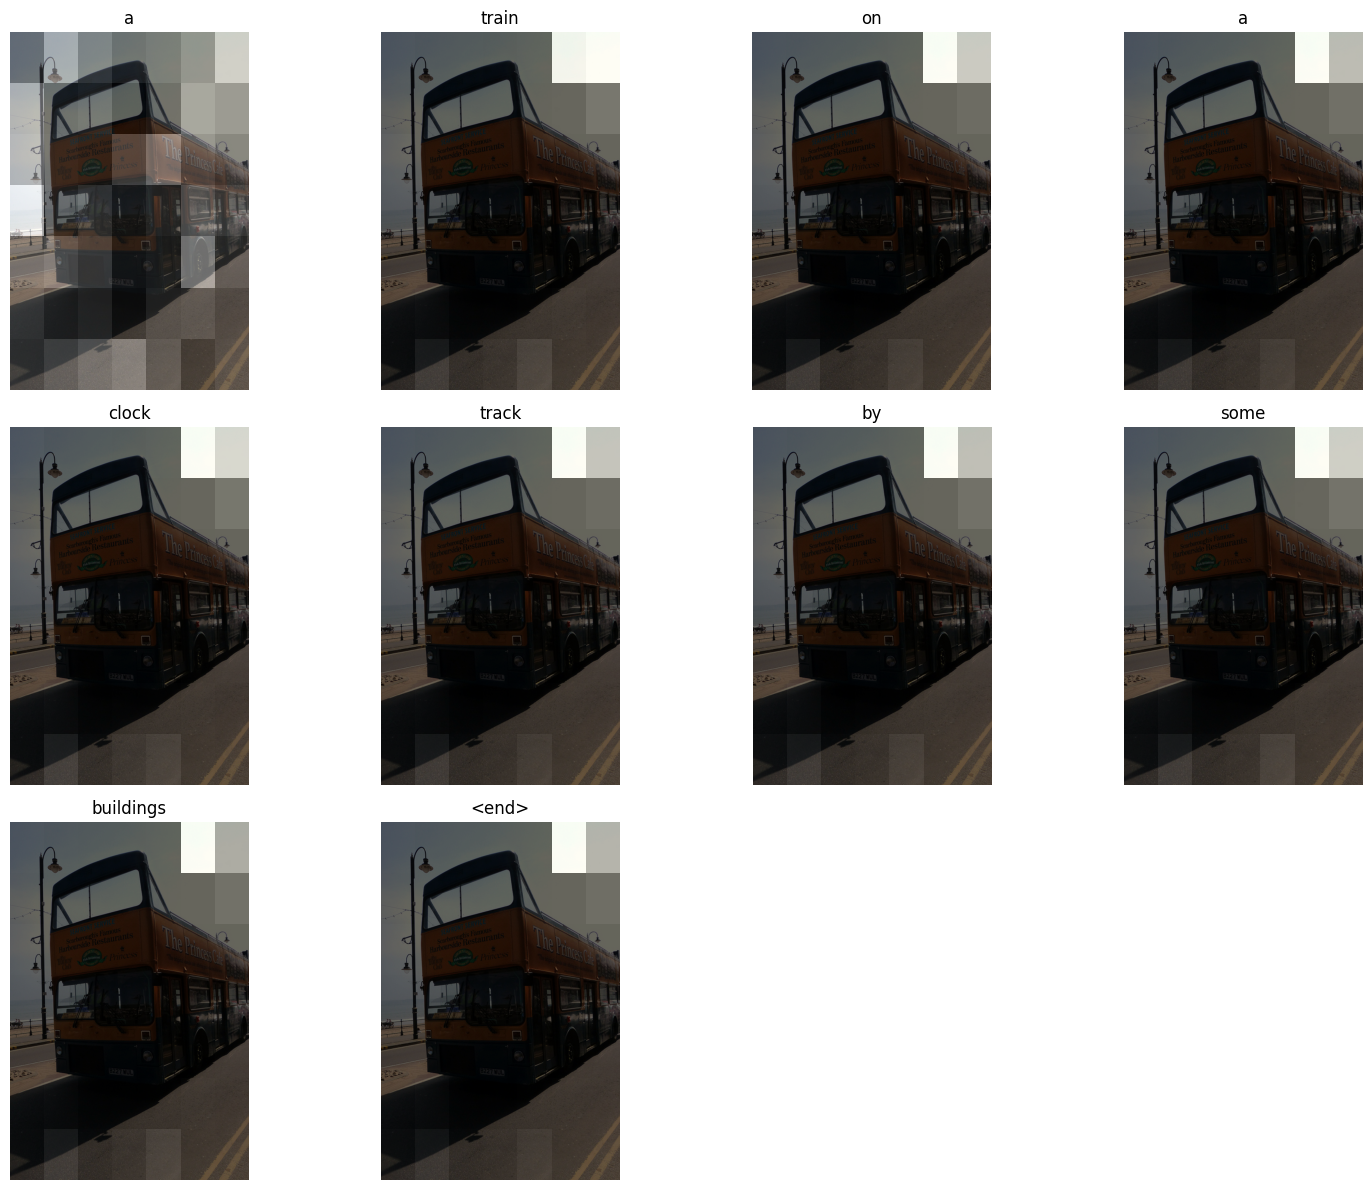

In [ ]:
import tensorflow as tf
import numpy as np
import math
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import os

# ==============================================================================
# 0. MISSING DEFINITIONS & SMART IMAGE DOWNLOADER
# ==============================================================================
max_length = cap_vector.shape[1]

def download_single_image(image_id):
    filename = f"COCO_train2014_{int(image_id):012d}.jpg"
    url = f"http://images.cocodataset.org/train2014/{filename}"
    local_path = f"/content/{filename}"

    if not os.path.exists(local_path):
        print(f"Downloading required image for testing: {filename}...")
        urllib.request.urlretrieve(url, local_path)

    return local_path

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, image_path

image_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
new_input = image_model.input
hidden_layer = image_model.layers[-1].output
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

# ==============================================================================
# 1. EVALUATION FUNCTION (Updated for Dynamic State Management)
# ==============================================================================
def evaluate(image_path, target_model):
    # Using 49 for VGG16 (7x7 feature map)
    attention_plot = np.zeros((max_length, 49))

    hidden = target_model.init_hidden_state(1)

    temp_input, _ = load_image(image_path)
    img_tensor_val = image_features_extract_model(tf.expand_dims(temp_input, 0))
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = target_model(dec_input, img_tensor_val, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()
        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

# ==============================================================================
# 2. PLOTTING ATTENTION HEATMAPS
# ==============================================================================
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))
    len_result = len(result)
    rows = math.ceil(len_result / 4)

    fig = plt.figure(figsize=(15, rows * 4))
    for l in range(len_result):
        temp_att = np.reshape(attention_plot[l], (7, 7))
        ax = fig.add_subplot(rows, 4, l + 1)
        ax.set_title(result[l], fontsize=12)
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. LOAD A SPECIFIC MODEL & TEST ON A RANDOM IMAGE
# ==============================================================================
print("Loading model for evaluation...")

# CHOOSE WHICH EXPERIMENT TO TEST (e.g., LSTM 1-Layer with Bahdanau)
test_cell = 'GRU'
test_layers = 2
test_attn = 'bahdanau'

# Re-instantiate the model structure
test_model = UniversalDecoder(embedding_dim, units, vocab_size, cell_type=test_cell, num_layers=test_layers, attention_type=test_attn)

# Initialize the model variables by passing dummy data
dummy_img_features = tf.random.uniform((1, 49, 512))

dummy_hidden = test_model.init_hidden_state(1)

dummy_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
_ = test_model(dummy_input, dummy_img_features, dummy_hidden)

# Load the saved weights from Drive
weight_filename = f"decoder_{test_cell}_L{test_layers}_{test_attn}.weights.h5"
weights_path = os.path.join(drive_project_path, weight_filename)

if os.path.exists(weights_path):
    test_model.load_weights(weights_path)
    print(f" Successfully loaded weights from: {weight_filename}")
else:
    print(f" Error: Could not find {weights_path}. Check if training is complete.")

# Pick a random image and evaluate
rid = np.random.randint(0, len(img_name_vector))
original_path = img_name_vector[rid]

image_id_str = original_path.split('_')[-1].split('.')[0]
local_image_path = download_single_image(image_id_str)

real_caption = ' '.join([tokenizer.index_word[i] for i in cap_vector[rid] if i not in [0]])

# Pass the test_model to the evaluate function
result, attention_plot = evaluate(local_image_path, test_model)

print('\nReal Caption:', real_caption)
print('Prediction Caption:', ' '.join(result))
plot_attention(local_image_path, result, attention_plot)

In [8]:
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2014.zip
!unzip -q annotations_trainval2014.zip

import tensorflow as tf
import os
import json
import collections
import random
import numpy as np
from google.colab import drive

# 1. DRIVE MOUNTING AND DATA LOADING
drive.mount('/content/drive')
drive_project_path = '/content/drive/MyDrive/MS_COCO_Project'
annotation_file = '/content/annotations/captions_train2014.json'
PATH = '/content/train2014/'

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption = f"<start> {val['caption']} <end>"
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    image_path_to_caption[image_path].append(caption)

image_paths = list(image_path_to_caption.keys())
random.seed(42)
random.shuffle(image_paths)

total_subset = image_paths[:30000]
split_index = int(len(total_subset) * 0.8)
train_image_paths = total_subset[:split_index]
val_image_paths = total_subset[split_index:]

def prepare_vectors(paths):
    captions = []
    names = []
    for image_path in paths:
        caption_list = image_path_to_caption[image_path]
        captions.extend(caption_list)
        names.extend([image_path] * len(caption_list))
    return captions, names

train_captions, img_name_vector = prepare_vectors(train_image_paths)

# 2. CREATING TOKENIZER AND CAP_VECTOR (The solution to the error is here!)
top_k = 5000
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k, oov_token="<unk>", filters=r'!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
tokenizer.fit_on_texts(train_captions)
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

train_seqs = tokenizer.texts_to_sequences(train_captions)
max_length = max(len(t) for t in train_seqs)
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, maxlen=max_length, padding='post')

# Parameters
BATCH_SIZE = 64
vocab_size = top_k + 1
embedding_dim = 256
units = 512

# 3. DEFINING MODEL ARCHITECTURE (Skeleton is required to load weights)
class GlobalAttention(tf.keras.Model):
    def __init__(self, units, attention_type='bahdanau'):
        super(GlobalAttention, self).__init__()
        self.attention_type = attention_type.lower()
        self.region_projector = tf.keras.layers.Dense(units)
        if self.attention_type == 'bahdanau':
            self.W1 = tf.keras.layers.Dense(units)
            self.W2 = tf.keras.layers.Dense(units)
            self.V = tf.keras.layers.Dense(1)
        elif self.attention_type == 'luong':
            self.W = tf.keras.layers.Dense(units)

    def call(self, features, hidden):
        features = self.region_projector(features)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        if self.attention_type == 'bahdanau':
            score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis)))
        elif self.attention_type == 'luong':
            query = self.W(hidden_with_time_axis)
            score = tf.matmul(features, query, transpose_b=True)
        else:
            dk = tf.cast(features.shape[-1], tf.float32)
            score = tf.matmul(features, hidden_with_time_axis, transpose_b=True) / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = tf.reduce_sum(attention_weights * features, axis=1)
        return context_vector, attention_weights

class UniversalDecoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, cell_type, num_layers, attention_type):
        super(UniversalDecoder, self).__init__()
        self.units = units
        self.cell_type = cell_type.upper()
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.attention = GlobalAttention(units, attention_type)
        self.rnn_cells = []
        for _ in range(num_layers):
            if self.cell_type == 'LSTM':
                self.rnn_cells.append(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
            else:
                self.rnn_cells.append(tf.keras.layers.GRU(units, return_sequences=True, return_state=True))
        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):
        h_query = hidden[0][0] if self.cell_type == 'LSTM' else hidden[0]
        context_vector, attention_weights = self.attention(features, h_query)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        new_hidden = []
        for i in range(self.num_layers):
            if self.cell_type == 'LSTM':
                x, h, c = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append([h, c])
            else:
                x, h = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append(h)
        x = self.fc2(self.fc1(x))
        return tf.reshape(x, (-1, x.shape[2])), new_hidden, attention_weights

    def init_hidden_state(self, batch_size):
        if self.cell_type == 'LSTM':
            return [[tf.zeros((batch_size, self.units)), tf.zeros((batch_size, self.units))] for _ in range(self.num_layers)]
        return [tf.zeros((batch_size, self.units)) for _ in range(self.num_layers)]

print("Preparation complete! You can now run the test (evaluate) code.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Preparation complete! You can now run the test (evaluate) code.


In [9]:
!pip install rouge-score -q
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
# ==============================================================================
# PHASE 1, 2 & 3: ULTIMATE COMPARATIVE EVALUATION (ALL 5 MODELS)
# ==============================================================================
!pip install rouge-score -q

import os
import urllib.request
import tensorflow as tf
import numpy as np
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import gc

print("\n>>> ULTIMATE EVALUATION STARTING (TESTING ALL 5 MODELS)...")

# --- 1. DEFINING BOTH DECODERS TO PREVENT CRASHES ---

# Baseline Decoder (For Phase 1 & 2 - No Attention)
class BaselineDecoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size, cell_type, num_layers):
        super(BaselineDecoder, self).__init__()
        self.units = units
        self.cell_type = cell_type.upper()
        self.num_layers = num_layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.feature_projector = tf.keras.layers.Dense(units)

        self.rnn_cells = []
        for _ in range(num_layers):
            if self.cell_type == 'LSTM':
                self.rnn_cells.append(tf.keras.layers.LSTM(units, return_sequences=True, return_state=True))
            else:
                self.rnn_cells.append(tf.keras.layers.GRU(units, return_sequences=True, return_state=True))

        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):
        features = self.feature_projector(features)
        context_vector = tf.reduce_mean(features, axis=1)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        new_hidden = []
        for i in range(self.num_layers):
            if self.cell_type == 'LSTM':
                x, h, c = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append([h, c])
            else:
                x, h = self.rnn_cells[i](x, initial_state=hidden[i])
                new_hidden.append(h)
        x = self.fc2(self.fc1(x))
        dummy_attention = tf.zeros((tf.shape(x)[0], 49))
        return tf.reshape(x, (-1, x.shape[2])), new_hidden, dummy_attention

    def init_hidden_state(self, batch_size):
        if self.cell_type == 'LSTM':
            return [[tf.zeros((batch_size, self.units)), tf.zeros((batch_size, self.units))] for _ in range(self.num_layers)]
        return [tf.zeros((batch_size, self.units)) for _ in range(self.num_layers)]

# --- 2. EVALUATION FUNCTION ---
def download_single_image(image_id_str):
    filename = f"COCO_train2014_{int(image_id_str):012d}.jpg"
    url = f"http://images.cocodataset.org/train2014/{filename}"
    local_path = f"/content/{filename}"
    if not os.path.exists(local_path):
        urllib.request.urlretrieve(url, local_path)
    return local_path

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.vgg16.preprocess_input(img)
    return img, image_path

image_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
image_features_extract_model = tf.keras.Model(image_model.input, image_model.layers[-1].output)

def evaluate(image_path, target_model):
    hidden = target_model.init_hidden_state(1)
    temp_input, _ = load_image(image_path)
    img_tensor_val = image_features_extract_model(tf.expand_dims(temp_input, 0))
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = target_model(dec_input, img_tensor_val, hidden)
        predicted_id = tf.argmax(predictions, axis=1).numpy()[0]
        result.append(tokenizer.index_word[predicted_id])
        if tokenizer.index_word[predicted_id] == '<end>':
            return result
        dec_input = tf.expand_dims([predicted_id], 0)
    return result

# --- 3. THE 5-MODEL MASTER LIST ---
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

test_list = [
    {'name': 'Phase 1: Baseline',        'file': 'baseline_GRU_L2.weights.h5',                'has_attn': False},
    {'name': 'Phase 2: Teacher Forcing', 'file': 'phase2_teacher_forcing_GRU_L2.weights.h5',  'has_attn': False},
    {'name': 'Phase 3: Bahdanau Attn',   'file': 'decoder_GRU_L2_bahdanau.weights.h5',        'has_attn': True, 'attn_type': 'bahdanau'},
    {'name': 'Phase 3: Luong Attn',      'file': 'decoder_GRU_L2_luong.weights.h5',           'has_attn': True, 'attn_type': 'luong'},
    {'name': 'Phase 3: Scaled Dot Attn', 'file': 'decoder_GRU_L2_scaled_dot.weights.h5',      'has_attn': True, 'attn_type': 'scaled_dot'}
]

results_table = []
unseen_test_paths = val_image_paths[:500]

for config in test_list:
    print(f"\nEvaluating: {config['name']}...")
    tf.keras.backend.clear_session()
    gc.collect()

    # Smart Model Instantiation
    if config['has_attn']:
        temp_model = UniversalDecoder(embedding_dim, units, vocab_size, 'GRU', 2, config['attn_type'])
    else:
        temp_model = BaselineDecoder(embedding_dim, units, vocab_size, 'GRU', 2)

    # Init variables
    _ = temp_model(tf.zeros((1, 1)), tf.zeros((1, 49, 512)), temp_model.init_hidden_state(1))

    weights_path = os.path.join(drive_project_path, config['file'])

    if os.path.exists(weights_path):
        temp_model.load_weights(weights_path)
    else:
        print(f"Skipping {config['name']}, file not found in Drive!")
        continue

    actuals, predicteds, meteors, rouges = [], [], [], []

    for img_path in unseen_test_paths:
        img_id = img_path.split('_')[-1].split('.')[0]
        local_path = download_single_image(img_id)

        result = evaluate(local_path, temp_model)

        ref_texts = [c.replace('<start>', '').replace('<end>', '').strip() for c in image_path_to_caption[img_path]]
        references = [c.split() for c in image_path_to_caption[img_path]]
        pred_text = ' '.join(result).replace('<end>', '').strip()

        actuals.append(references)
        predicteds.append(result)
        meteors.append(meteor_score(references, result))
        r_scores = [scorer.score(rt, pred_text)['rougeL'].fmeasure for rt in ref_texts]
        rouges.append(max(r_scores))

    b1 = corpus_bleu(actuals, predicteds, weights=(1.0, 0, 0, 0))
    b4 = corpus_bleu(actuals, predicteds, weights=(0.25, 0.25, 0.25, 0.25))

    results_table.append({
        'Model': config['name'],
        'BLEU-1': b1,
        'BLEU-4': b4,
        'METEOR': np.mean(meteors),
        'ROUGE_L': np.mean(rouges)
    })

# ==============================================================================
# ULTIMATE TABLE PRINTING (Ready for Word Document)
# ==============================================================================
print("\n" + "="*95)
print(f"{'Project Progression (Table 2)':<35} | {'BLEU-1':<10} | {'BLEU-4':<10} | {'METEOR':<10} | {'ROUGE_L':<10}")
print("-" * 95)
for res in results_table:
    print(f"{res['Model']:<35} | {res['BLEU-1']:<10.4f} | {res['BLEU-4']:<10.4f} | {res['METEOR']:<10.4f} | {res['ROUGE_L']:<10.4f}")
print("="*95)

import pandas as pd

df_results = pd.DataFrame(results_table)

csv_save_path = os.path.join(drive_project_path, "Table2_Ultimate_Results.csv")

df_results.to_csv(csv_save_path, index=False)

print(f"\n Great! The results table has been successfully saved to Drive:")
print(csv_save_path)


>>> ULTIMATE EVALUATION STARTING (TESTING ALL 5 MODELS)...

Evaluating: Phase 1: Baseline...

Evaluating: Phase 2: Teacher Forcing...

Evaluating: Phase 3: Bahdanau Attn...

Evaluating: Phase 3: Luong Attn...

Evaluating: Phase 3: Scaled Dot Attn...

Project Progression (Table 2)       | BLEU-1     | BLEU-4     | METEOR     | ROUGE_L   
-----------------------------------------------------------------------------------------------
Phase 1: Baseline                   | 0.4313     | 0.0308     | 0.2205     | 0.3734    
Phase 2: Teacher Forcing            | 0.5703     | 0.1254     | 0.3479     | 0.4524    
Phase 3: Bahdanau Attn              | 0.5595     | 0.1215     | 0.3415     | 0.4451    
Phase 3: Luong Attn                 | 0.4522     | 0.0312     | 0.2317     | 0.3686    
Phase 3: Scaled Dot Attn            | 0.4023     | 0.0120     | 0.1881     | 0.3429    

 Great! The results table has been successfully saved to Drive:
/content/drive/MyDrive/MS_COCO_Project/Table2_Ultimate_Resu